# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [52]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Exploratory Data Analysis  
- Load in the cleaned data

In [53]:
# Loading data using pandas
data = pd.read_csv("final_cleaned_aviation_data.csv", encoding="latin-1")
data

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,...,Weather.Condition,Broad.phase.of.flight,Publication.Date,Total.Passengers,% Fatal.Injuries,% Serious.Injuries,% Minor.Injuries,% Serious/Fatal.Injured,aircraft.destroyed,Aircraft.Type
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,Incident,Minor,Airplane,9VSQQ,...,VMC,Taxi,04-12-2014,588.0,0.0,0.0,0.0,0.0,False,BOEING 747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,Fatal(1),Destroyed,Airplane,N9600W,...,IMC,Cruise,02-05-2011,2.0,50.0,50.0,0.0,100.0,True,PIPER PA-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,Fatal(1),Unknown,Airplane,N927BA,...,VMC,Standing,17-10-2016,5.0,20.0,0.0,0.0,20.0,False,DE HAVILLAND DHC-6
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,Incident,Minor,Airplane,N898AA,...,VMC,Taxi,11-06-2018,100.0,0.0,0.0,0.0,0.0,False,BOEING 727-200
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,Non-Fatal,Substantial,Airplane,N1882D,...,VMC,Climb,05-05-2011,1.0,0.0,0.0,0.0,0.0,False,BEECH C35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17887,20221212106444,Accident,ERA23LA085,2022-12-12,"Knoxville, TN",United States,Non-Fatal,Substantial,Airplane,N783SF,...,VMC,NaN,15-12-2022,1.0,0.0,0.0,0.0,0.0,False,CESSNA 172
17888,20221213106455,Accident,WPR23LA065,2022-12-13,"Lewistown, MT",United States,Non-Fatal,Substantial,Airplane,C-GZPU,...,NaN,NaN,14-12-2022,1.0,0.0,0.0,0.0,0.0,False,PIPER PA42
17889,20221215106463,Accident,ERA23LA090,2022-12-14,"San Juan, PR",United States,Non-Fatal,Substantial,Airplane,N416PC,...,VMC,NaN,27-12-2022,1.0,0.0,0.0,0.0,0.0,False,CIRRUS SR22
17890,20221219106470,Accident,ERA23LA091,2022-12-16,"Brooksville, FL",United States,Minor,Substantial,Airplane,N5405V,...,VMC,NaN,23-12-2022,1.0,0.0,100.0,0.0,100.0,False,CESSNA R172K


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [54]:
# Filtering the aircrafts, large and small, acording to the 20 threshold
small = data[data['Total.Passengers'] <= 20].copy()
large = data[data['Total.Passengers'] > 20].copy()

print(f"Small aircraft records: {len(small)}")
print(f"Large aircraft records: {len(large)}")

Small aircraft records: 17019
Large aircraft records: 873


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [55]:
# Compute mean serious/fatal injury fraction per Make for small and large aircraft
# Keep makes with at least 10 records for robustness

small_make_stats = (
    small.groupby('Make')['% Serious/Fatal.Injured']
    .agg(['mean', 'count'])
    .query('count >= 10')
    .sort_values('mean')
    .head(15)
    .reset_index()
)

large_make_stats = (
    large.groupby('Make')['% Serious/Fatal.Injured']
    .agg(['mean', 'count'])
    .query('count >= 10')
    .sort_values('mean')
    .head(15)
    .reset_index()
)

print("Top 15 safest small aircraft makes (mean serious/fatal injury rate):")
print(small_make_stats[['Make','mean','count']].to_string(index=False))
print()
print("Top 15 safest large aircraft makes (mean serious/fatal injury rate):")
print(large_make_stats[['Make','mean','count']].to_string(index=False))

Top 15 safest small aircraft makes (mean serious/fatal injury rate):
                    Make      mean  count
       mcdonnell douglas  9.404762     30
              bombardier  9.837278     26
                  boeing 14.197270    272
                   maule 16.480620    215
                   aviat 19.178082    146
                   ayres 20.370370     54
                 stinson 21.640827    129
                bellanca 22.260274    219
diamond aircraft ind inc 22.297297     74
  rockwell international 22.368421     57
                 aeronca 22.583333    200
                champion 26.269841    210
                  cessna 26.396300   7062
                  airbus 27.601810     13
                luscombe 28.014184    141

Top 15 safest large aircraft makes (mean serious/fatal injury rate):
             Make     mean  count
mcdonnell douglas 0.782706     53
       bombardier 4.017776     64
           boeing 5.677074    547
          embraer 6.527402     78
           airbus 8

OBSERVATION

Some aircraft makes like bombardier and airbus appear in both the large and small aircrafts due to different passenger capacity for different planes.

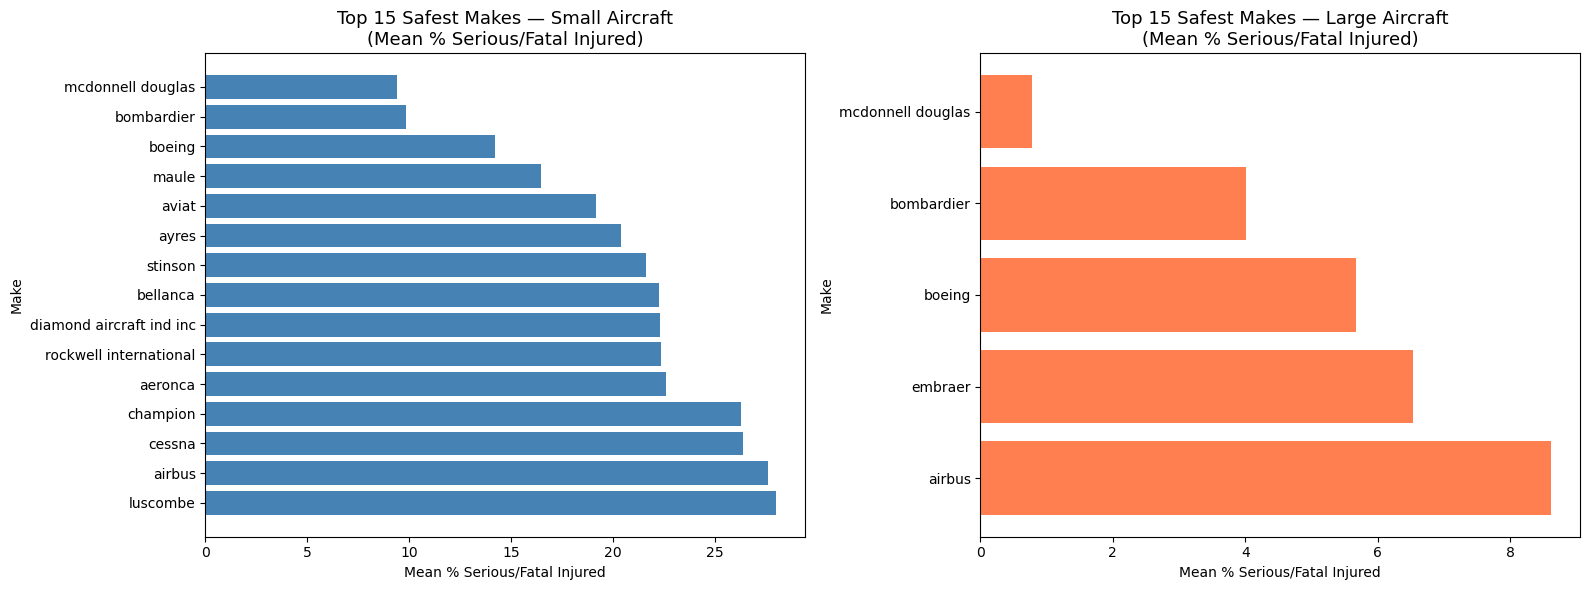

In [56]:
# Side-by-side bar chart: mean fatal/seriously injured fraction for top 15 makes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Small aircraft
axes[0].barh(small_make_stats['Make'][::-1], small_make_stats['mean'][::-1], color='steelblue')
axes[0].set_title('Top 15 Safest Makes — Small Aircraft\n(Mean % Serious/Fatal Injured)', fontsize=13)
axes[0].set_xlabel('Mean % Serious/Fatal Injured')
axes[0].set_ylabel('Make')

# Large aircraft
axes[1].barh(large_make_stats['Make'][::-1], large_make_stats['mean'][::-1], color='coral')
axes[1].set_title('Top 15 Safest Makes — Large Aircraft\n(Mean % Serious/Fatal Injured)', fontsize=13)
axes[1].set_xlabel('Mean % Serious/Fatal Injured')
axes[1].set_ylabel('Make')

plt.tight_layout()
plt.savefig('makes_injury_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

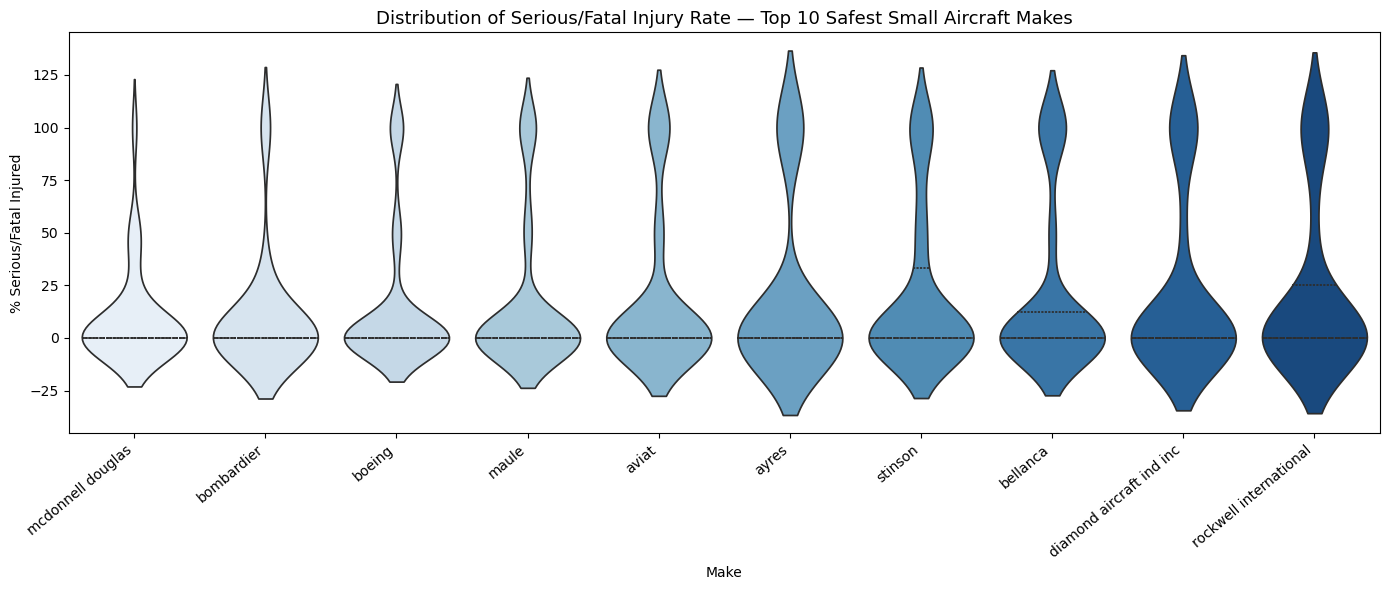

In [57]:
# Violin plot: distribution of injury rates for top 10 small makes
top10_small_makes = small_make_stats.head(10)['Make'].tolist()
small_top10 = small[small['Make'].isin(top10_small_makes)].copy()

# Order makes by mean injury rate
make_order = small_make_stats.head(10)['Make'].tolist()

plt.figure(figsize=(14, 6))
sns.violinplot(
    data=small_top10,
    x='Make', y='% Serious/Fatal.Injured',
    order=make_order,
    palette='Blues',
    inner='quartile'
)
plt.title('Distribution of Serious/Fatal Injury Rate — Top 10 Safest Small Aircraft Makes', fontsize=13)
plt.xlabel('Make')
plt.ylabel('% Serious/Fatal Injured')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('violin_small_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

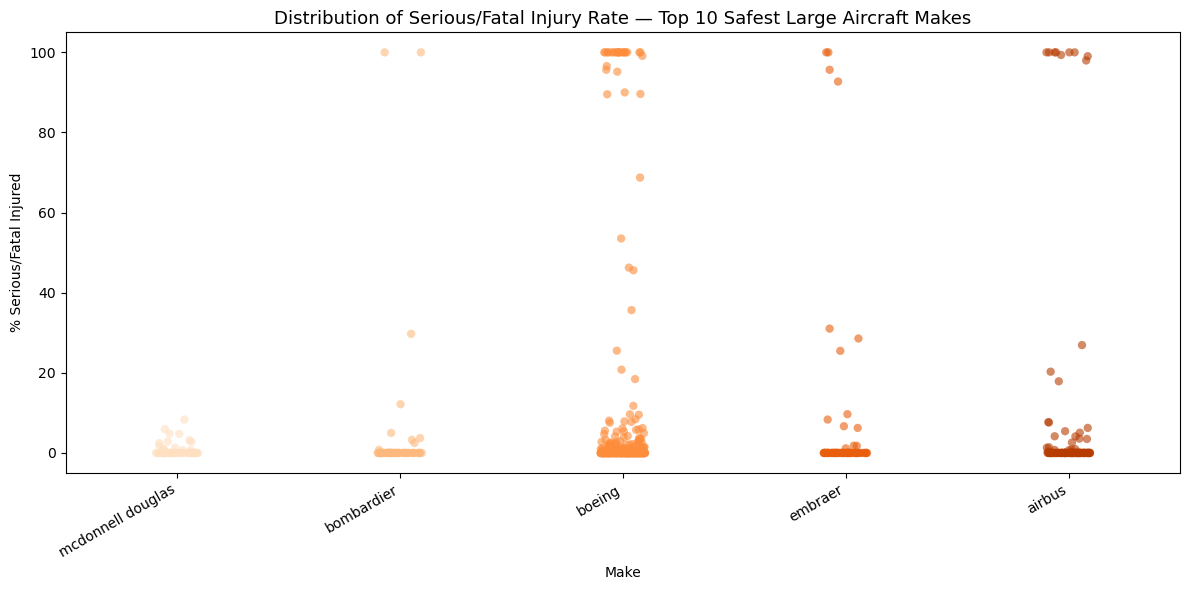

In [58]:
# Strip plot: distribution of injury rates for top 10 large makes
top10_large_makes = large_make_stats.head(10)['Make'].tolist()
large_top10 = large[large['Make'].isin(top10_large_makes)].copy()

make_order_large = large_make_stats.head(10)['Make'].tolist()

plt.figure(figsize=(12, 6))
sns.stripplot(
    data=large_top10,
    x='Make', y='% Serious/Fatal.Injured',
    order=make_order_large,
    palette='Oranges',
    jitter=True, alpha=0.6, size=6
)
plt.title('Distribution of Serious/Fatal Injury Rate — Top 10 Safest Large Aircraft Makes', fontsize=13)
plt.xlabel('Make')
plt.ylabel('% Serious/Fatal Injured')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('strip_large_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [59]:
# Aircraft destruction rate by Make — top 15 safest for small and large
small_destroyed = (
    small.groupby('Make')['aircraft.destroyed']
    .agg(['mean', 'count'])
    .query('count >= 10')
    .rename(columns={'mean': 'Destruction Rate', 'count': 'N'})
    .sort_values('Destruction Rate')
    .head(15)
    .reset_index()
)
small_destroyed['Destruction Rate (%)'] = (small_destroyed['Destruction Rate'] * 100).round(2)

large_destroyed = (
    large.groupby('Make')['aircraft.destroyed']
    .agg(['mean', 'count'])
    .query('count >= 10')
    .rename(columns={'mean': 'Destruction Rate', 'count': 'N'})
    .sort_values('Destruction Rate')
    .head(15)
    .reset_index()
)
large_destroyed['Destruction Rate (%)'] = (large_destroyed['Destruction Rate'] * 100).round(2)

print("Top 15 Lowest Aircraft Destruction Rates — Small Aircraft:")
print(small_destroyed[['Make','Destruction Rate (%)','N']].to_string(index=False))
print()
print("Top 15 Lowest Aircraft Destruction Rates — Large Aircraft:")
print(large_destroyed[['Make','Destruction Rate (%)','N']].to_string(index=False))

Top 15 Lowest Aircraft Destruction Rates — Small Aircraft:
                    Make  Destruction Rate (%)    N
                luscombe                  1.42  141
                 stinson                  2.33  129
                  airbus                  2.40  125
             taylorcraft                  3.23   93
                 aeronca                  3.50  200
                  boeing                  3.63  717
                 ercoupe                  3.85   52
              bombardier                  3.92   51
                   maule                  4.19  215
                bellanca                  5.02  219
diamond aircraft ind inc                  5.41   74
                champion                  6.67  210
                   aviat                  6.85  146
       mcdonnell douglas                  7.27   55
                  cessna                  9.50 7144

Top 15 Lowest Aircraft Destruction Rates — Large Aircraft:
             Make  Destruction Rate (%)   N
     

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.


### Discussion: Findings by Make
Looking at the bar chart and violin plot, manufacturers like **Mcdonnel douglas**, **Bombardier**, and **Boeing** consistently show the lowest mean injury rates among small aircraft involved in accidents.However these are large commercial manufacturers whose small aircrafts  are likely regional jets operated professionally. Manufacturers like **Aviat** and **Maule** have higher mean injury rates and wide distributions, suggesting more variability in outcomes.


**Large aircraft:**
For larger planes, **McDonnell Douglas**, **Bombardier**, and **Boeing** have the lowest average injury rates. The strip plot shows that most accidents for these manufacturers cluster near zero meaning injuries are rare when they do occur.

**Destruction rates:**
Destruction rates are lower for large commercial manufacturers consistent with the robustness of commercial airframes and professional maintenance standards. For small aircraft, destruction rates vary significantly across makes, suggesting build quality and design robustness differ meaningfully.

**Make Recommendations:**
- *Large aircraft*: Boeing, McDonnell Douglas, and Bombardier Inc stand out as safest across both metrics.
- *Small aircraft*: Airbus and Bombardier lead on injury rates; however, given the lower sample sizes for these, Cessna and Maule warrant consideration for their sheer volume of data points though with higher average injury rates.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Large aircraft models with ≥10 records: 14
         Aircraft.Type      mean  count
            BOEING 777  0.082099     33
            BOEING 757  0.147287     18
            BOEING 787  0.305832     11
        BOEING 737-7H4  0.324230     12
BOMBARDIER CL-600-2B19  0.413580     15
        EMBRAER EMB145  0.879765     11
     EMBRAER EMB-145LR  1.000000     15
            BOEING 747  2.316150     11
            BOEING 767  4.696260     31
        BOEING 737 7H4  6.812081     14
            BOEING 737  8.122258    163
           AIRBUS A320 12.669399     24
           AIRBUS A330 14.687192     14
           AIRBUS A321 20.000000     10


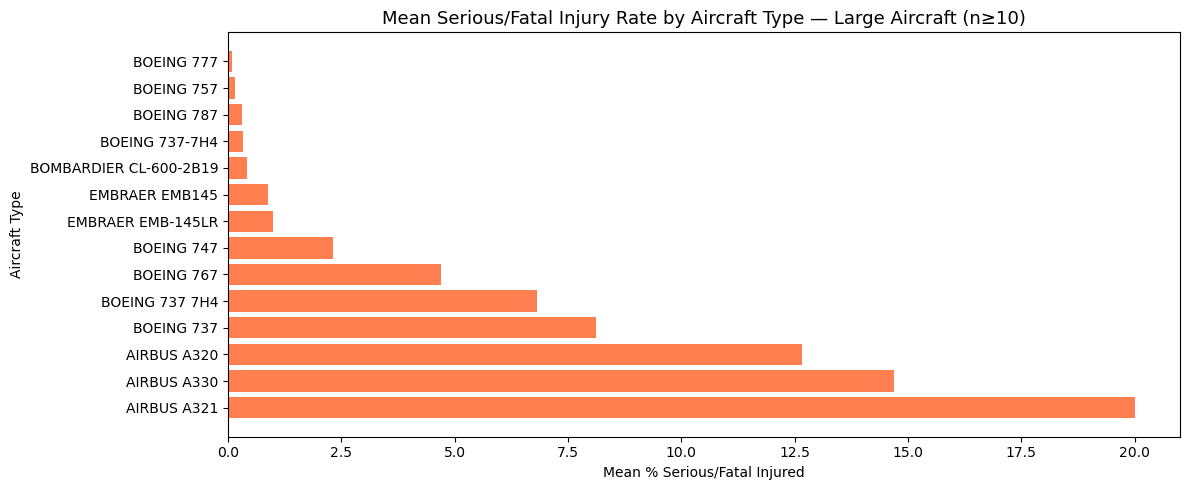

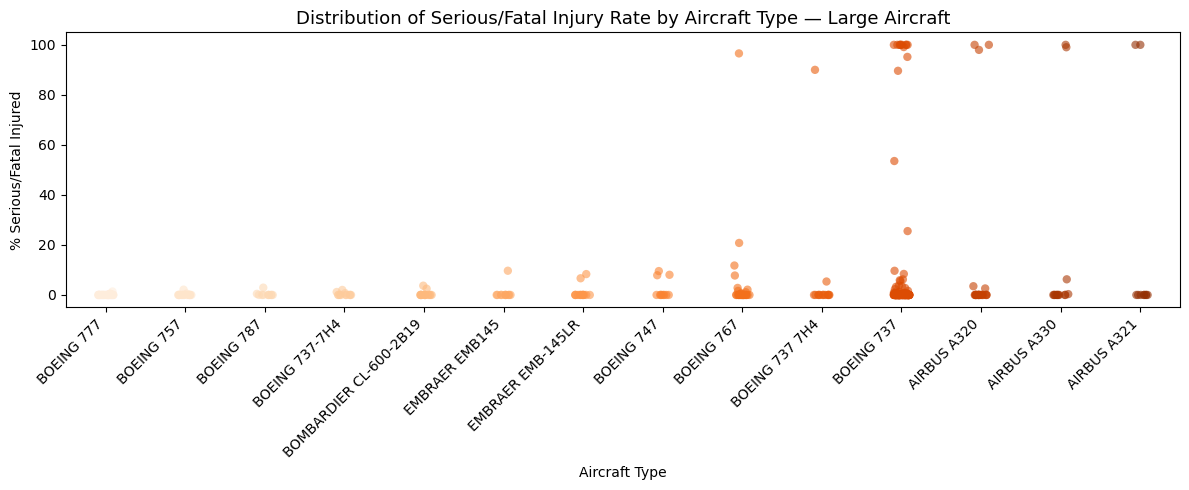

In [60]:
# Large aircraft — mean injury rate by specific Aircraft.Type (min 10 examples)
large_model_stats = (
    large.groupby('Aircraft.Type')['% Serious/Fatal.Injured']
    .agg(['mean', 'count'])
    .query('count >= 10')
    .sort_values('mean')
    .reset_index()
)

print(f"Large aircraft models with ≥10 records: {len(large_model_stats)}")
print(large_model_stats.to_string(index=False))

# Bar chart
plt.figure(figsize=(12, 5))
plt.barh(large_model_stats['Aircraft.Type'][::-1], large_model_stats['mean'][::-1], color='coral')
plt.title('Mean Serious/Fatal Injury Rate by Aircraft Type — Large Aircraft (n≥10)', fontsize=13)
plt.xlabel('Mean % Serious/Fatal Injured')
plt.ylabel('Aircraft Type')
plt.tight_layout()
plt.savefig('large_model_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribution plot
plt.figure(figsize=(12, 5))
model_order_large = large_model_stats['Aircraft.Type'].tolist()
large_filtered = large[large['Aircraft.Type'].isin(model_order_large)]
sns.stripplot(data=large_filtered, x='Aircraft.Type', y='% Serious/Fatal.Injured',
              order=model_order_large, jitter=True, alpha=0.6, palette='Oranges', size=6)
plt.title('Distribution of Serious/Fatal Injury Rate by Aircraft Type — Large Aircraft', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Aircraft Type')
plt.ylabel('% Serious/Fatal Injured')
plt.tight_layout()
plt.savefig('large_model_strip.png', dpi=150, bbox_inches='tight')
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Top 10 safest small aircraft types (n≥10):
                    Aircraft.Type     mean  count
                   MAULE M-5-210C 0.000000     11
DIAMOND AIRCRAFT IND INC DA 20 C1 0.000000     11
                     CESSNA 172SP 0.000000     12
                      CESSNA 180J 3.571429     28
                     CESSNA A185E 3.888889     18
                      PIPER PA-20 4.000000     25
                        BEECH B19 4.166667     16
                     CESSNA 560XL 4.761905     21
                      CESSNA 180H 4.901961     34
                       CESSNA 195 4.954955     37


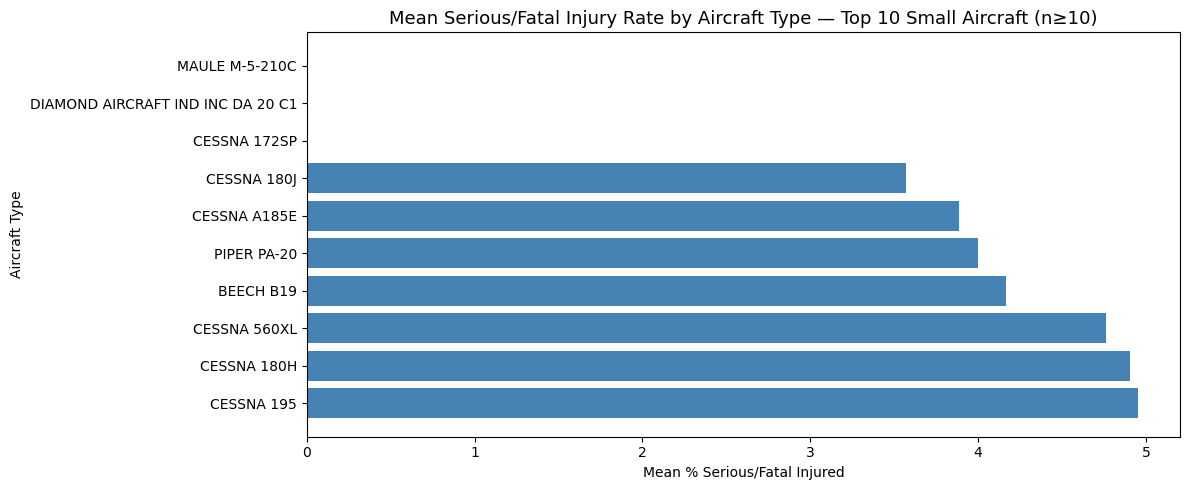

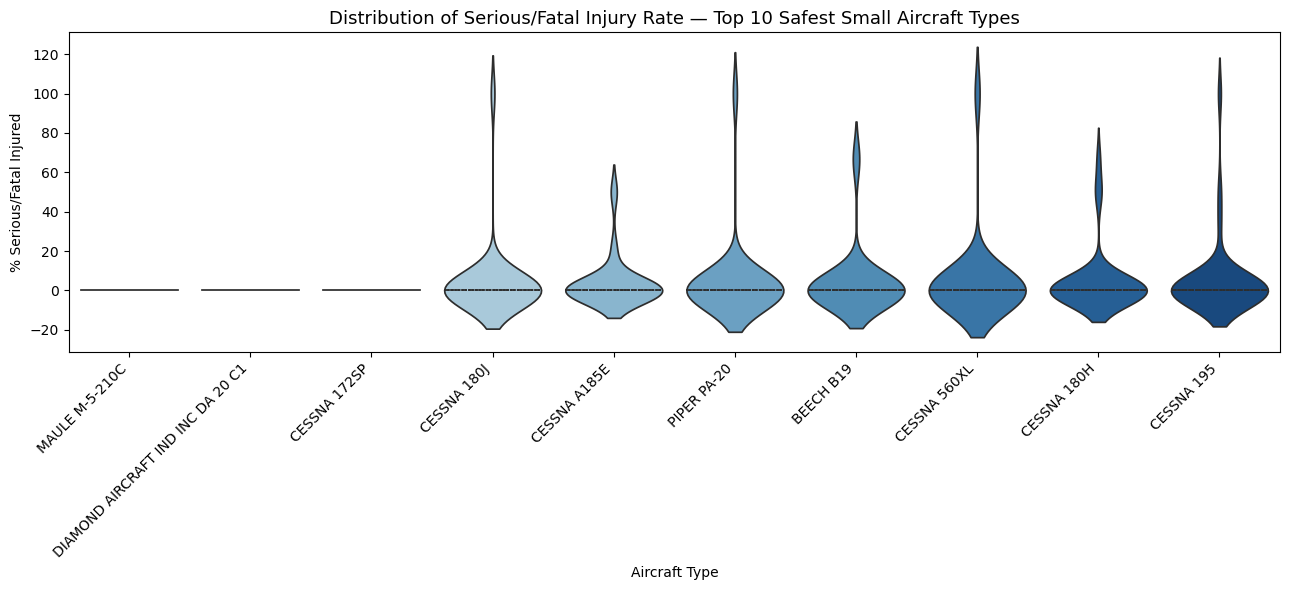

In [61]:
# Small aircraft — mean injury rate by Aircraft.Type (min 10 examples, top 10 lowest)
small_model_stats = (
    small.groupby('Aircraft.Type')['% Serious/Fatal.Injured']
    .agg(['mean', 'count'])
    .query('count >= 10')
    .sort_values('mean')
    .head(10)
    .reset_index()
)

print("Top 10 safest small aircraft types (n≥10):")
print(small_model_stats.to_string(index=False))

# Bar chart
plt.figure(figsize=(12, 5))
plt.barh(small_model_stats['Aircraft.Type'][::-1], small_model_stats['mean'][::-1], color='steelblue')
plt.title('Mean Serious/Fatal Injury Rate by Aircraft Type — Top 10 Small Aircraft (n≥10)', fontsize=13)
plt.xlabel('Mean % Serious/Fatal Injured')
plt.ylabel('Aircraft Type')
plt.tight_layout()
plt.savefig('small_model_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Violin distribution
small_models_filtered = small[small['Aircraft.Type'].isin(small_model_stats['Aircraft.Type'])]
plt.figure(figsize=(13, 6))
sns.violinplot(data=small_models_filtered, x='Aircraft.Type', y='% Serious/Fatal.Injured',
               order=small_model_stats['Aircraft.Type'].tolist(),
               palette='Blues', inner='quartile')
plt.title('Distribution of Serious/Fatal Injury Rate — Top 10 Safest Small Aircraft Types', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Aircraft Type')
plt.ylabel('% Serious/Fatal Injured')
plt.tight_layout()
plt.savefig('small_model_violin.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion: Findings by Specific Model

**Large aircraft models:**
The **Boeing 777**, **Boeing 757**, and **Boeing 787** emerge as the safest large models, with mean injury rates close to zero. These are modern wide body jets with strong safety records. The **Boeing 737** series shows a higher mean injury rate partly explained by its much larger sample size (more accidents over its long operational history). The Airbus A321 has the highest average injury rate.

**Small aircraft models:**
Among small models with enough data, the **Cessna 172SP**, **Diamond Aircraft DA 20 C1**, and **Maule M-5-210C** have the lowest average injury rates, several sitting at zero. However, the strip plots show these are skewed by many zero-injury incidents When injuries do occur, they can be severe.

**Overall model recommendations:**
- *Large*: Boeing 777 and Boeing 757 are the top recommendations for the insurer.
- *Small*: Cessna 172SP and Diamond DA 20 are strong candidates for low-injury small aircraft.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### Factor 1: Weather Condition

**VMC** = Visual Meteorological Conditions (clear weather, pilots navigate by sight)
**IMC** = Instrument Meteorological Conditions (low visibility, pilots rely on instruments)

**Hypothesis:** Accidents in IMC (poor weather) are likely to result in more severe outcomes.

In [62]:
# Filter to only known weather conditions (drop 'UNK' = unknown)
weather_data = data[data['Weather.Condition'].isin(['VMC', 'IMC'])].copy()

# Summary statistics by weather condition
weather_summary = weather_data.groupby('Weather.Condition').agg(
    Accident_Count=('% Serious/Fatal.Injured', 'count'),
    Mean_Injury_Rate=('% Serious/Fatal.Injured', 'mean'),
    Median_Injury_Rate=('% Serious/Fatal.Injured', 'median'),
    Destruction_Rate=('aircraft.destroyed', 'mean')
).round(3)

# Convert destruction rate to percentage
weather_summary['Destruction_Rate'] = (weather_summary['Destruction_Rate'] * 100).round(1)

print('Summary Statistics by Weather Condition:')
display(weather_summary)

Summary Statistics by Weather Condition:


,Accident_Count,Mean_Injury_Rate,Median_Injury_Rate,Destruction_Rate
Weather.Condition,,,,
IMC,896,62.842,100.0,34.9
VMC,14253,23.301,0.0,7.1


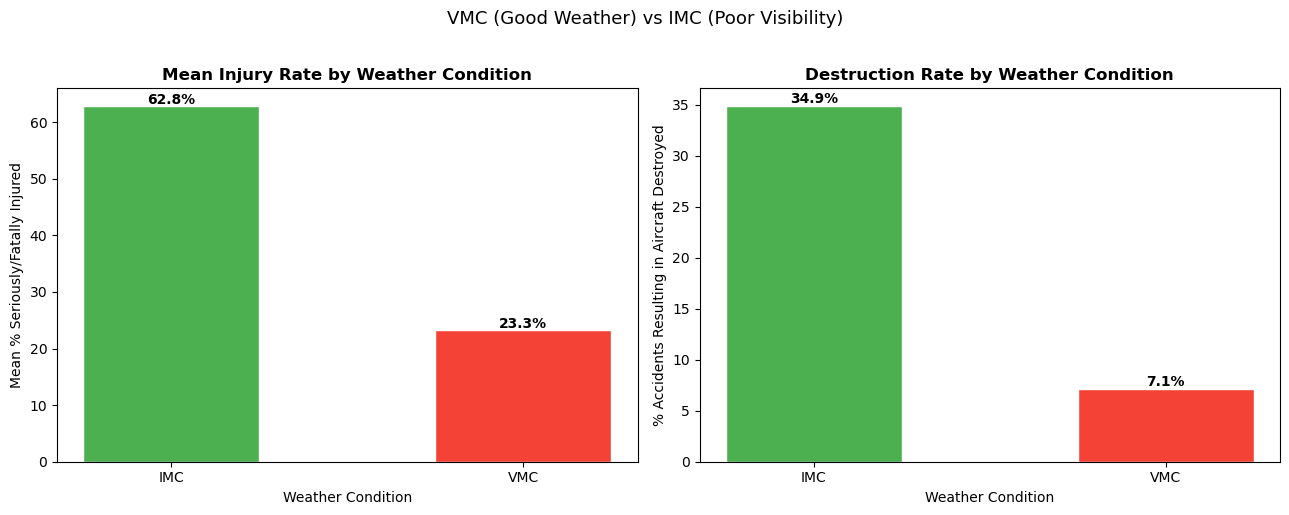

In [63]:
# --- Side-by-side bar charts for weather ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Mean injury rate by weather
weather_injury = weather_data.groupby('Weather.Condition')['% Serious/Fatal.Injured'].mean()
axes[0].bar(weather_injury.index, weather_injury.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Mean Injury Rate by Weather Condition', fontweight='bold')
axes[0].set_ylabel('Mean % Seriously/Fatally Injured')
axes[0].set_xlabel('Weather Condition')
for i, v in enumerate(weather_injury.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Chart 2: Destruction rate by weather
weather_dest = weather_data.groupby('Weather.Condition')['aircraft.destroyed'].mean() * 100
axes[1].bar(weather_dest.index, weather_dest.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
axes[1].set_title('Destruction Rate by Weather Condition', fontweight='bold')
axes[1].set_ylabel('% Accidents Resulting in Aircraft Destroyed')
axes[1].set_xlabel('Weather Condition')
for i, v in enumerate(weather_dest.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('VMC (Good Weather) vs IMC (Poor Visibility)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

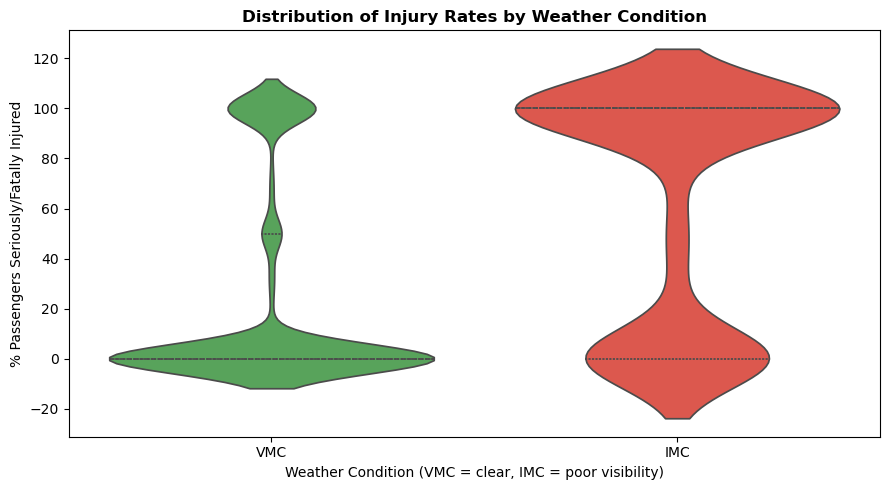

In [64]:
# Violin plot — shows the full distribution of injury rates by weather
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=weather_data,
    x='Weather.Condition',
    y='% Serious/Fatal.Injured',
    palette={'VMC': '#4CAF50', 'IMC': '#F44336'},
    inner='quartile'
)
plt.title('Distribution of Injury Rates by Weather Condition', fontweight='bold')
plt.xlabel('Weather Condition (VMC = clear, IMC = poor visibility)')
plt.ylabel('% Passengers Seriously/Fatally Injured')
plt.tight_layout()
plt.show()

#### Discussion: Weather Condition

The data clearly shows that accidents occurring in **IMC** result in significantly higher injury rates and destruction rates compared to **VMC** accidents.
The violin plots confirm that the IMC distribution is heavier in the high injury region, while VMC accidents cluster near zero.
Aircraft operating frequently in IMC conditions (e.g., regional routes with frequent fog or mountain terrain) represent a higher risk profile and may warrant adjusted premiums.

### Factor 2: Engine Type

Different engine technologies have different reliability profiles:
- **Reciprocating** = traditional piston engines (common in small private planes)
- **Turbo prop** = propeller driven by a turbine (regional aircraft)
- **Turbo fan / Turbo jet** = jet engines (commercial airliners)

**Hypothesis:** Jet-powered aircraft (turbo fan / turbo jet) may show lower injury rates due to better maintenance standards and redundancy in commercial operations.

In [65]:
# Focus on the main engine types (exclude 'unknown' and rare categories)
main_engines = ['reciprocating', 'turbo prop', 'turbo fan', 'turbo jet']
engine_data = data[data['Engine.Type'].isin(main_engines)].copy()

# Summary statistics by engine type
engine_summary = engine_data.groupby('Engine.Type').agg(
    Accident_Count=('% Serious/Fatal.Injured', 'count'),
    Mean_Injury_Rate=('% Serious/Fatal.Injured', 'mean'),
    Median_Injury_Rate=('% Serious/Fatal.Injured', 'median'),
    Destruction_Rate=('aircraft.destroyed', 'mean')
).round(3)

engine_summary['Destruction_Rate'] = (engine_summary['Destruction_Rate'] * 100).round(1)

# Sort by mean injury rate
engine_summary = engine_summary.sort_values('Mean_Injury_Rate')

print('Summary Statistics by Engine Type:')
display(engine_summary)

Summary Statistics by Engine Type:


,Accident_Count,Mean_Injury_Rate,Median_Injury_Rate,Destruction_Rate
Engine.Type,,,,
turbo fan,590,8.981,0.0,5.0
turbo jet,66,19.502,0.0,15.5
reciprocating,12815,25.421,0.0,7.8
turbo prop,918,32.093,0.0,18.3


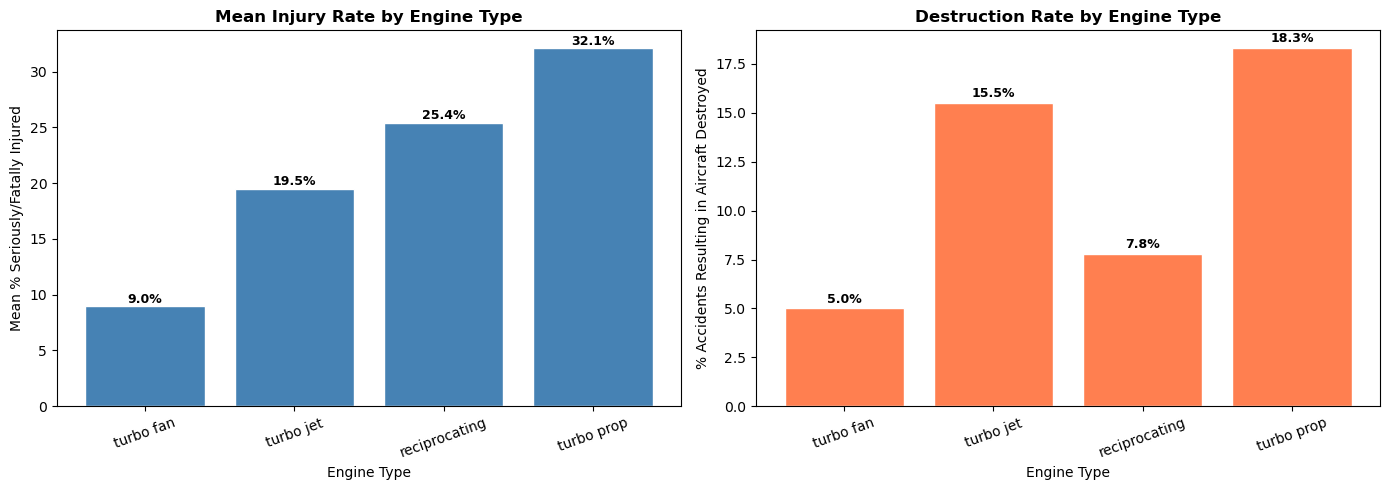

In [66]:
# --- Bar charts for engine type ---
engine_order = engine_summary.index.tolist()  # sorted by injury rate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Mean injury rate
injury_vals = engine_summary['Mean_Injury_Rate']
axes[0].bar(injury_vals.index, injury_vals.values, color='steelblue', edgecolor='white')
axes[0].set_title('Mean Injury Rate by Engine Type', fontweight='bold')
axes[0].set_xlabel('Engine Type')
axes[0].set_ylabel('Mean % Seriously/Fatally Injured')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(injury_vals.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Chart 2: Destruction rate
dest_vals = engine_summary['Destruction_Rate']
axes[1].bar(dest_vals.index, dest_vals.values, color='coral', edgecolor='white')
axes[1].set_title('Destruction Rate by Engine Type', fontweight='bold')
axes[1].set_xlabel('Engine Type')
axes[1].set_ylabel('% Accidents Resulting in Aircraft Destroyed')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(dest_vals.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Discussion: Engine Type

The analysis reveals that **turbo fan** and **turbo jet** aircraft have  lower mean injury and destruction rates compared to reciprocating and turbo prop.
The box plots show that the median injury rate for turbo fan/jet accidents is near zero, with a small number of high-injury outliers. Reciprocating engine accidents, by contrast, show a much wider spread. Many accidents are mild, but the severe ones are more common.






### FINAL RECOMMENDATION
**Large aircraft:** Boeing and McDonnell Douglas models (especially the 777 and 757) consistently show the lowest injury rates

**Small aircraft:** Cessna 172SP and Diamond DA-20 stand out as the safest small plane models

**Weather matters:** Accidents in poor visibility (IMC) are significantly more severe than those in clear conditions

**Engine type matters:** Jet-powered aircraft have far lower injury rates than piston-engine planes largely because jets are operated commercially with professional crews and stricter maintenance